<a href="https://colab.research.google.com/github/SugiShanmu/Machine-Learning-/blob/main/PolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Experience Education  Salary_k
0            1       BSc        15
1            2       BSc        18
2            3       MSc        28
3            4       MSc        40
4            5       MSc        55
5            6       PhD        75
6            7       PhD        95
7            8       BSc        20
8            9       MSc        45
9           10       PhD       110
10          11       MSc        60
11          12       PhD       125

R2 Score: 0.885
RMSE: 11.65


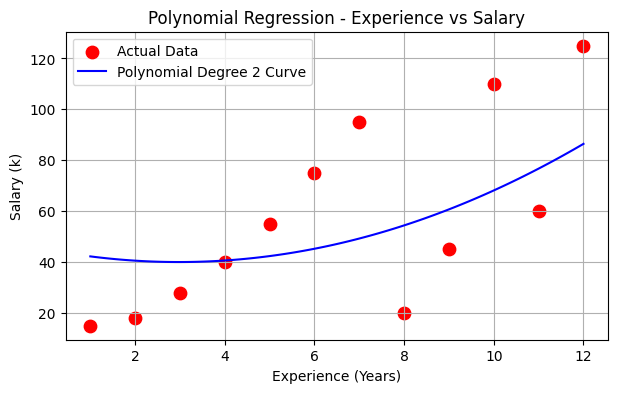

Saved: polynomial_regression.png

How it works:
1. Experience scaled: (value-mean)/std
2. Polynomial created: Exp, Exp^2
3. Education encoded: BSc=0, MSc/PhD=1
4. Linear Regression fits on those new features


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. SAMPLE DATA - Salary vs Experience (Non-linear)
data = {
    'Experience': [1,2,3,4,5,6,7,8,9,10,11,12],
    'Education': ['BSc','BSc','MSc','MSc','MSc','PhD','PhD','BSc','MSc','PhD','MSc','PhD'],
    'Salary_k': [15,18,28,40,55,75,95,20,45,110,60,125]
}
df = pd.DataFrame(data)
print(df)

# 2. X, y
X = df[['Experience','Education']]
y = df['Salary_k']

# 3. PREPROCESSING
# Polynomial works on numeric only after scaling
numeric_features = ['Experience']
categorical_features = ['Education']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler()),           # Feature Scaling / Normalization
        ('poly', PolynomialFeatures(degree=2, include_bias=False)) # Polynomial
    ]), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features) # Encoding
])

# 4. PIPELINE
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. TRAIN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)

# 6. PREDICT
y_pred = model.predict(X_test)
print(f"\nR2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 7. VISUALIZATION - Curve
# For smooth curve, sort by Experience
X_plot = pd.DataFrame({
    'Experience': np.linspace(df['Experience'].min(), df['Experience'].max(), 100),
    'Education': ['MSc']*100
})
y_plot = model.predict(X_plot)

plt.figure(figsize=(7,4))
plt.scatter(df['Experience'], df['Salary_k'], color='red', label='Actual Data', s=80)
plt.plot(X_plot['Experience'], y_plot, color='blue', label='Polynomial Degree 2 Curve')
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (k)")
plt.title("Polynomial Regression - Experience vs Salary")
plt.legend()
plt.grid(True)
plt.show()

plt.savefig("polynomial_regression.png")
print("Saved: polynomial_regression.png")

# 8. What happened inside?
print("\nHow it works:")
print("1. Experience scaled: (value-mean)/std")
print("2. Polynomial created: Exp, Exp^2")
print("3. Education encoded: BSc=0, MSc/PhD=1")
print("4. Linear Regression fits on those new features")